In [1]:
#dummy model
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load data
train_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

X = train_df["comment"]
y = train_df["label"]

# Train / validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train.values.reshape(-1, 1), y_train)

# Validation accuracy
y_val_pred = dummy.predict(X_val.values.reshape(-1, 1))
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))

# Test predictions
test_preds = dummy.predict(test_df["comment"].values.reshape(-1, 1))





Validation Accuracy: 0.5766414141414141


#  Comment Category Prediction Challenge

This project aims to predict the final category assigned to user-generated comments in an online discussion system.

Each comment is associated with:
- Text content
- User engagement signals (e.g., votes)
- Symbolic expressions (e.g., emoticons)
- Topic reference indicators
- Internal system-generated signals

---

##  Objective

Build a machine learning model that accurately predicts how each comment is categorized by the system using a combination of:
- Textual features
- Numerical metadata
- Engineered signals

---

##  Key Challenge

This is not just a text classification problem — it involves **multi-source feature integration**, requiring the model to learn from:
- Natural language patterns
- User interaction behavior
- Platform-specific signals

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
import lightgbm as lgb

##  Understanding the Dataset

Each row represents a single comment submitted to an online platform.

### Feature Types:

- **Textual Data**
  - Raw comment text

- **Engagement Signals**
  - Upvotes / Downvotes
  - Reflect user interaction and sentiment

- **Symbolic Indicators**
  - Emoticons and special patterns
  - Provide implicit emotional context

- **System Signals**
  - Outputs from internal automated analysis
  - Likely already encode platform-specific heuristics

---

##  Key Insight

The target label is not purely based on text — it is influenced by:
- Community feedback
- System-level processing
- Contextual signals

This makes the problem more complex and realistic.

##  Text Preprocessing

Raw comments may contain:
- Noise (URLs, special characters)
- Inconsistent formatting

### Steps Applied:
- Convert text to lowercase
- Remove URLs and unwanted symbols
- Normalize whitespace

---

##  Insight

Cleaning improves:
- Consistency across samples
- Quality of TF-IDF features

However, excessive cleaning may remove useful signals (e.g., emoticons), so a balance is important.

In [3]:
import re  
import pandas as pd

train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

train["comment"] = train["comment"].fillna("")
test_df["comment"] = test_df["comment"].fillna("")

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9\s!?.,']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train["comment"] = train["comment"].apply(clean_text)
test_df["comment"] = test_df["comment"].apply(clean_text)

X = train["comment"]
y = train["label"]

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

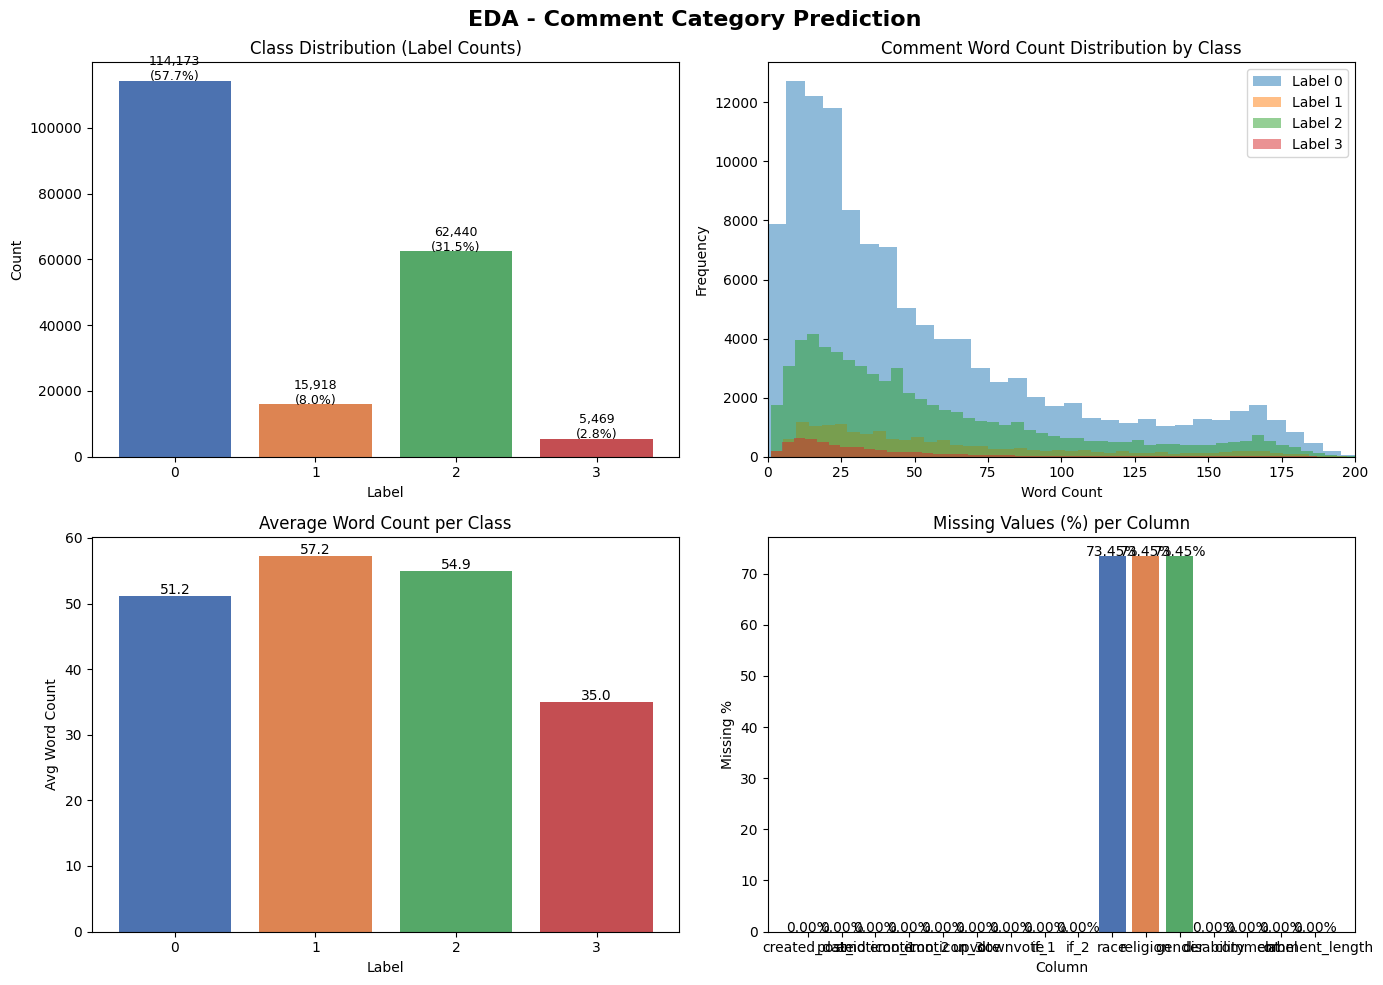

EDA charts saved!


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
train["comment"] = train["comment"].fillna("")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EDA - Comment Category Prediction", fontsize=16, fontweight="bold")

ax1 = axes[0, 0]
class_counts = train["label"].value_counts().sort_index()
bars = ax1.bar(class_counts.index.astype(str), class_counts.values, 
               color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
ax1.set_title("Class Distribution (Label Counts)")
ax1.set_xlabel("Label")
ax1.set_ylabel("Count")
for bar, val in zip(bars, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f"{val:,}\n({val/len(train)*100:.1f}%)", ha="center", fontsize=9)

ax2 = axes[0, 1]
train["comment_length"] = train["comment"].apply(lambda x: len(x.split()))
for label in sorted(train["label"].unique()):
    subset = train[train["label"] == label]["comment_length"]
    ax2.hist(subset, bins=50, alpha=0.5, label=f"Label {label}")
ax2.set_title("Comment Word Count Distribution by Class")
ax2.set_xlabel("Word Count")
ax2.set_ylabel("Frequency")
ax2.set_xlim(0, 200)
ax2.legend()

ax3 = axes[1, 0]
avg_len = train.groupby("label")["comment_length"].mean()
bars3 = ax3.bar(avg_len.index.astype(str), avg_len.values,
                color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
ax3.set_title("Average Word Count per Class")
ax3.set_xlabel("Label")
ax3.set_ylabel("Avg Word Count")
for bar, val in zip(bars3, avg_len.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val:.1f}", ha="center", fontsize=10)

ax4 = axes[1, 1]
missing = train.isnull().sum()
missing_pct = (missing / len(train)) * 100
cols = missing_pct.index.tolist()
vals = missing_pct.values.tolist()
bars4 = ax4.bar(cols, vals, color=["#4C72B0", "#DD8452", "#55A868"])
ax4.set_title("Missing Values (%) per Column")
ax4.set_xlabel("Column")
ax4.set_ylabel("Missing %")
for bar, val in zip(bars4, vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.2f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("eda_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA charts saved!")

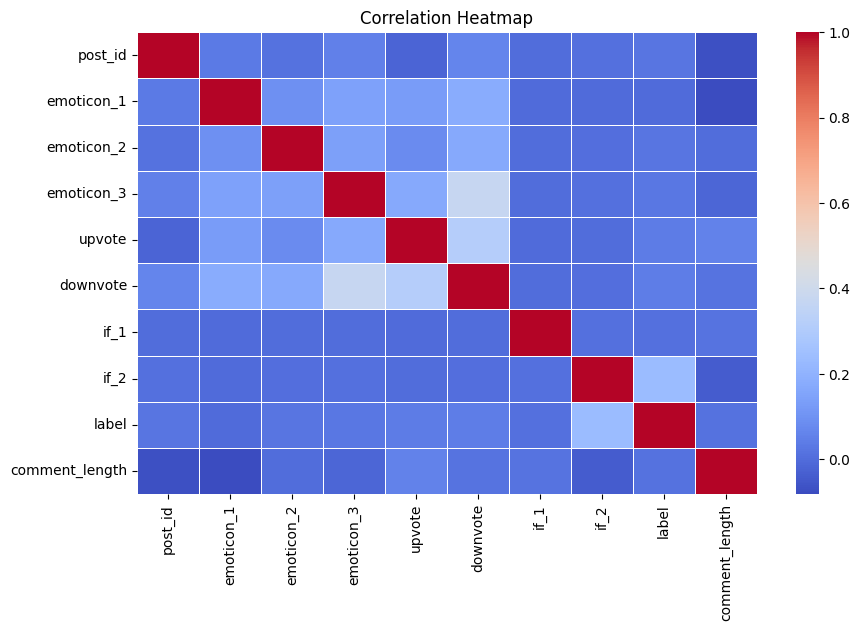

In [6]:

import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = train.select_dtypes(include=['number'])

plt.figure(figsize=(10, 6))
sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=False,      
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [7]:
print(train.columns.tolist())
print(train.head())

['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment', 'label', 'comment_length']
                       created_date  post_id  emoticon_1  emoticon_2  \
0  2024-01-18 08:43:57.397508+00:00       73           0           0   
1  2024-03-24 21:43:11.490017+00:00       39           0           0   
2  2024-04-24 20:32:17.014931+00:00       31           0           1   
3  2023-05-28 22:00:14.214527+00:00       39           0           0   
4  2023-09-09 23:12:05.689498+00:00       39           0           0   

   emoticon_3  upvote  downvote  if_1  if_2 race religion gender  disability  \
0           0       0         1     0    10  NaN      NaN    NaN       False   
1           0       6         0     0     4  NaN      NaN    NaN       False   
2           1       0         0     0    10  NaN      NaN    NaN       False   
3           0       5         0     0    10  NaN      NaN

##  Feature Engineering

To capture the full complexity of the problem, we construct features from multiple sources:

###  Text Features
- TF-IDF representation of comments
- Captures word importance and context

###  Numerical Features
- Comment length
- Upvotes / Downvotes

###  Symbolic Features
- Presence of emoticons
- Encodes emotional tone

---

##  Insight

The model benefits from combining:
- **What is said** (text)
- **How people react** (engagement)
- **How the system interprets it** (signals)

This multi-modal approach is critical for better performance.

In [8]:
from scipy.sparse import hstack
import scipy.sparse as sp
import numpy as np

train["comment_length"] = train["comment"].apply(lambda x: len(x.split()))
test_df["comment_length"] = test_df["comment"].apply(lambda x: len(x.split()))

num_cols = ["upvote", "downvote", "if_1", "if_2",
            "emoticon_1", "emoticon_2", "emoticon_3", "comment_length"]

train[num_cols] = train[num_cols].fillna(0)
test_df[num_cols] = test_df[num_cols].fillna(0)

word_tfidf = TfidfVectorizer(
    max_features=30000, ngram_range=(1, 2),
    sublinear_tf=True, analyzer="word",
    strip_accents="unicode", min_df=3
)
char_tfidf = TfidfVectorizer(
    max_features=20000, ngram_range=(2, 4),
    sublinear_tf=True, analyzer="char_wb", min_df=3
)

X_train_w = word_tfidf.fit_transform(X_train)
X_val_w   = word_tfidf.transform(X_val)
X_test_w  = word_tfidf.transform(test_df["comment"])

X_train_c = char_tfidf.fit_transform(X_train)
X_val_c   = char_tfidf.transform(X_val)
X_test_c  = char_tfidf.transform(test_df["comment"])

X_train_num = sp.csr_matrix(train[num_cols].iloc[X_train.index].values)
X_val_num   = sp.csr_matrix(train[num_cols].iloc[X_val.index].values)
X_test_num  = sp.csr_matrix(test_df[num_cols].values)

X_train_f = hstack([X_train_w, X_train_c, X_train_num])
X_val_f   = hstack([X_val_w, X_val_c, X_val_num])
X_test_f  = hstack([X_test_w, X_test_c, X_test_num])

print("Feature matrix shape:", X_train_f.shape)

Feature matrix shape: (158400, 50008)


##  Model 1: Linear SVM (Calibrated)

We train a **Linear Support Vector Machine (SVM)** as our first model.

###  Model Setup
- **LinearSVC** is used for efficient training on high-dimensional sparse data (TF-IDF)
- **Class weighting (`balanced`)** is applied to handle class imbalance
- **Max iterations increased** to ensure convergence

---

###  Probability Calibration

Since `LinearSVC` does not provide probability outputs, we wrap it with:

- **CalibratedClassifierCV (cv=3)**

This enables:
- Better probability estimates
- More reliable predictions
- Compatibility with ensemble methods (if used later)

---

###  Evaluation

We evaluate using:
- **Macro F1 Score** → treats all classes equally
- **Classification Report** → detailed per-class performance

---

###  Key Insight

- Linear SVM performs very well on **sparse text features**
- It captures strong linear decision boundaries in high-dimensional space
- Calibration improves prediction reliability, especially for imbalanced data

---

###  Limitations

- Cannot capture complex non-linear relationships
- Performance depends heavily on feature quality (e.g., TF-IDF setup)

---

###  Takeaway

This model serves as a **strong baseline**, particularly effective for:
- Text-heavy features
- High-dimensional sparse representations

In [9]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score, classification_report

print("=" * 40)
print("MODEL 1: Linear SVM")
print("=" * 40)

svm = CalibratedClassifierCV(LinearSVC(C=0.5, max_iter=2000, class_weight="balanced"), cv=3)
svm.fit(X_train_f, y_train)
svm_pred = svm.predict(X_val_f)
print("Macro F1:", f1_score(y_val, svm_pred, average="macro"))
print(classification_report(y_val, svm_pred))

MODEL 1: Linear SVM
Macro F1: 0.6758241514825678
              precision    recall  f1-score   support

           0       0.81      0.91      0.86     22835
           1       0.75      0.59      0.66      3183
           2       0.80      0.71      0.75     12488
           3       0.69      0.31      0.43      1094

    accuracy                           0.80     39600
   macro avg       0.76      0.63      0.68     39600
weighted avg       0.80      0.80      0.80     39600



##  Model 2: SGD Classifier

We train a **Stochastic Gradient Descent (SGD) Classifier**, a fast and scalable linear model suitable for large and sparse datasets.

---

###  Model Configuration

- **Loss Function: `modified_huber`**
  - Combines benefits of hinge loss (SVM) and logistic regression
  - Robust to outliers and provides smoother predictions

- **Regularization (`alpha=1e-4`)**
  - Helps prevent overfitting

- **Class Weighting (`balanced`)**
  - Adjusts for class imbalance automatically

- **Parallel Processing (`n_jobs=-1`)**
  - Utilizes all CPU cores for faster training

---

###  Why SGD?

- Efficient for **large-scale data**
- Works well with **high-dimensional sparse features** (like TF-IDF)
- Much faster than traditional SVM while maintaining comparable performance

---

###  Evaluation

We evaluate using:
- **Macro F1 Score** → ensures equal importance to all classes
- **Classification Report** → detailed precision, recall, and F1 per class

---

###  Key Insight

- SGD performs similarly to linear models like SVM but is significantly faster
- The `modified_huber` loss provides a balance between margin-based and probabilistic approaches
- Well-suited for iterative experimentation and large datasets

---

###  Limitations

- Sensitive to hyperparameters (learning rate, alpha)
- May require tuning for optimal performance
- Still a linear model → limited in capturing complex feature interactions

---

###  Takeaway

SGD is a **strong and efficient alternative to SVM**, making it ideal for:
- Fast experimentation
- Large datasets
- Sparse feature spaces

In [10]:
from sklearn.linear_model import SGDClassifier

print("=" * 40)
print("MODEL 2: SGD Classifier")
print("=" * 40)

sgd = SGDClassifier(
    loss="modified_huber",
    alpha=1e-4,
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
sgd.fit(X_train_f, y_train)
sgd_pred = sgd.predict(X_val_f)
print("Macro F1:", f1_score(y_val, sgd_pred, average="macro"))
print(classification_report(y_val, sgd_pred))

MODEL 2: SGD Classifier
Macro F1: 0.7061153136170741
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     22835
           1       0.59      0.65      0.62      3183
           2       0.83      0.79      0.81     12488
           3       0.45      0.48      0.47      1094

    accuracy                           0.85     39600
   macro avg       0.70      0.71      0.71     39600
weighted avg       0.86      0.85      0.85     39600



##  Model 3: LightGBM (Gradient Boosting)

We train a **LightGBM Classifier**, a powerful gradient boosting model capable of capturing complex patterns in the data.

---

###  Model Configuration

- **Objective: `multiclass`**
  - Suitable for multi-class classification tasks

- **n_estimators = 500**
  - Number of trees (controlled using early stopping)

- **learning_rate = 0.1**
  - Balances learning speed and model performance

- **num_leaves = 63**
  - Controls model complexity and ability to learn non-linear patterns

- **subsample = 0.8**
  - Reduces overfitting by using random subsets of data

- **colsample_bytree = 0.3**
  - Randomly selects features for each tree

- **min_child_samples = 50**
  - Prevents overfitting by limiting small leaf nodes

---

###  Handling Class Imbalance

We use:
- **Sample Weights (`compute_sample_weight`)**

This ensures:
- Minority classes are not ignored
- Balanced learning across all categories

---

###  Early Stopping

- Stops training if validation performance does not improve for **30 rounds**
- Prevents overfitting
- Improves efficiency

---

###  Evaluation

We evaluate using:
- **Macro F1 Score** → treats all classes equally
- **Classification Report** → detailed per-class performance

---

###  Key Insight

- LightGBM captures:
  - Feature interactions
  - Non-linear relationships
  - Combined effects of text and metadata

- Particularly useful here because:
  - The dataset contains **multi-modal features**
  - Patterns are not purely linear

---

###  Limitations

- Can overfit if not properly tuned
- Sensitive to hyperparameters
- May not fully leverage very sparse text features compared to linear models

---

###  Takeaway

LightGBM complements linear models by learning:
- Complex patterns
- Interactions between features

This makes it a strong component in a **hybrid modeling approach**

In [11]:
from sklearn.utils.class_weight import compute_sample_weight

print("=" * 40)
print("MODEL 3: LightGBM")
print("=" * 40)

sample_weights = compute_sample_weight("balanced", y=y_train)

lgb_model = lgb.LGBMClassifier(
    objective="multiclass",
    n_estimators=500,
    learning_rate=0.1,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.3,
    min_child_samples=50,
    force_col_wise=True,
    n_jobs=-1
)
lgb_model.fit(
    X_train_f, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val_f, y_val)],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(50)]
)

lgb_pred = lgb_model.predict(X_val_f)
print("Macro F1:", f1_score(y_val, lgb_pred, average="macro"))
print(classification_report(y_val, lgb_pred))

MODEL 3: LightGBM
[LightGBM] [Info] Total Bins 5056212
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 44829
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Training until validation scores don't improve for 30 rounds
[50]	valid_0's multi_logloss: 0.347615
[100]	valid_0's multi_logloss: 0.28304
[150]	valid_0's multi_logloss: 0.26595
[200]	valid_0's multi_logloss: 0.258835
[250]	valid_0's multi_logloss: 0.255692
[300]	valid_0's multi_logloss: 0.254505
Early stopping, best iteration is:
[303]	valid_0's multi_logloss: 0.254438


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Macro F1: 0.831159157896084
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.74      0.85      0.79      3183
           2       0.88      0.90      0.89     12488
           3       0.66      0.70      0.68      1094

    accuracy                           0.92     39600
   macro avg       0.82      0.85      0.83     39600
weighted avg       0.92      0.92      0.92     39600



In [12]:
import os
os.listdir('/kaggle/working')

['eda_charts.png', '__notebook__.ipynb']

##  Results Summary & Model Comparison

We compare the performance of all trained models using **Macro F1 Score**:

- **Linear SVM**
- **SGD Classifier**
- **LightGBM**

---

###  Best Performing Model: LightGBM

From the results, **LightGBM achieves the highest Macro F1 score**, outperforming both linear models.

---

###  Key Observations

- **Linear Models (SVM, SGD):**
  - Perform well on high-dimensional text features (TF-IDF)
  - Capture strong linear patterns in the data
  - Limited in modeling complex relationships

- **LightGBM:**
  - Effectively captures **non-linear relationships**
  - Learns **interactions between text and numerical features**
  - Handles **multi-modal data** (text + metadata + system signals) more efficiently

---

###  Insight

The superior performance of LightGBM indicates that:
- The problem is not purely linear
- Feature interactions and non-linear patterns play a significant role
- Metadata and system-level signals contribute meaningful information

---

###  Conclusion

While linear models provide strong baselines, **LightGBM emerges as the most effective model** for this task due to its ability to:
- Capture complex patterns
- Leverage combined feature types
- Improve overall classification performance

In [13]:
print("\n" + "=" * 40)
print("RESULTS SUMMARY")
print("=" * 40)
print(f"Linear SVM  → Macro F1: {f1_score(y_val, svm_pred, average='macro'):.4f}")
print(f"SGD         → Macro F1: {f1_score(y_val, sgd_pred, average='macro'):.4f}")
print(f"LightGBM    → Macro F1: {f1_score(y_val, lgb_pred, average='macro'):.4f}")

test_preds = lgb_model.predict(X_test_f)
submission = pd.DataFrame({
    "ID": sample_df["ID"],
    "label": test_preds
})
submission.to_csv("submission.csv", index=False)
print("submission.csv saved!")


RESULTS SUMMARY
Linear SVM  → Macro F1: 0.6758
SGD         → Macro F1: 0.7061
LightGBM    → Macro F1: 0.8312


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


submission.csv saved!
